Two sources:
1. `src/dictionary_collection/mturk/analysis`
2. `src/data_term_gold/processed`

In [1]:
import pandas as pd
import json
data_gold = pd.read_json("/home/jiaruil5/multilingual/multilingual-model-card/src/data_term_gold/russian.json").rename(columns={"term_english": "word", "term_russian": "validated_translation"}, inplace=False).drop_duplicates(subset='word', inplace=False)
data_gold['word_lower'] = data_gold['word'].str.lower()
data_6060 = pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_results_6060/Russian_validated.csv").drop_duplicates(subset='word', inplace=False)
data_mturk = pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_results_crawled/Russian_validated.csv").drop_duplicates(subset='word', inplace=False)

In [2]:
concat_df = pd.concat([data_6060[['word', 'validated_translation']], data_mturk[['word', 'validated_translation']]], axis=0, ignore_index=True)
concat_df['word_lower'] = concat_df['word'].str.lower()
concat_df

,word,validated_translation,word_lower
0,AI,ИИ,ai
1,API,API,api
2,AQA,AQA,aqa
3,ARENA,АРЕНА,arena
4,Additionally,Дополнительно,additionally
...,...,...,...
4985,zero-shot prompting,запрос без примеров,zero-shot prompting
4986,zero-shot reasoning,рассуждение без примеров,zero-shot reasoning
4987,zero-shot setting,Настройка без примеров,zero-shot setting
4988,zero-shot transfer,нулевой перенос,zero-shot transfer


In [3]:
df_itst = pd.merge(data_gold[['word', 'word_lower', 'validated_translation']], concat_df[['word', 'word_lower', 'validated_translation']], on='word_lower')
df_itst[df_itst['validated_translation_x'] == df_itst['validated_translation_y']].shape[0] / df_itst.shape[0], df_itst[df_itst['validated_translation_x'] == df_itst['validated_translation_y']].shape[0], df_itst.shape[0]

(0.5569620253164557, 44, 79)

In [4]:
def levenshtein_distance(str1, str2):
    # Initialize matrix of distances
    dp = [[0] * (len(str2) + 1) for _ in range(len(str1) + 1)]

    # Base cases
    for i in range(len(str1) + 1):
        dp[i][0] = i
    for j in range(len(str2) + 1):
        dp[0][j] = j

    # Fill the matrix
    for i in range(1, len(str1) + 1):
        for j in range(1, len(str2) + 1):
            if str1[i - 1] == str2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]  # No operation needed
            else:
                dp[i][j] = min(dp[i - 1][j] + 1,      # Deletion
                               dp[i][j - 1] + 1,      # Insertion
                               dp[i - 1][j - 1] + 1)  # Substitution

    # The distance is in the bottom-right cell
    return dp[-1][-1]

df_itst['levenshtein_dist'] = df_itst.apply(lambda x: levenshtein_distance(x['validated_translation_x'], x['validated_translation_y']), axis=1)

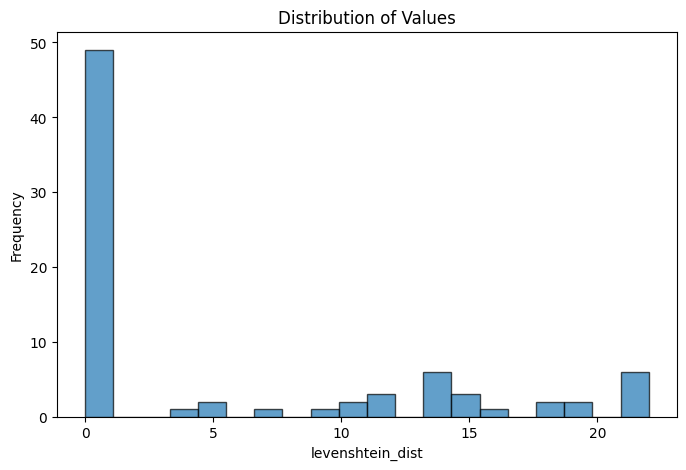

In [6]:
import matplotlib.pyplot as plt
import pandas as pd


# Plot the distribution of the 'values' column
plt.figure(figsize=(8, 5))
plt.hist(df_itst['levenshtein_dist'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('levenshtein_dist')
plt.ylabel('Frequency')
plt.title('Distribution of Values')
plt.show()


In [4]:
merged_df = pd.merge(concat_df[['word', 'word_lower', 'validated_translation']], data_gold[['word', 'word_lower', 'validated_translation']], on="word_lower", how='outer', suffixes=('_df2', '_df1'))
merged_df

,word_df2,word_lower,validated_translation_df2,word_df1,validated_translation_df1
0,10-fold cross validation,10-fold cross validation,10-кратная кросс-валидация,NaN,NaN
1,1D convolution,1d convolution,1D свертка,NaN,NaN
2,2 norm,2 norm,2-норма,NaN,NaN
3,2D convolution,2d convolution,2D свертка,NaN,NaN
4,2D image,2d image,2D изображение,NaN,NaN
...,...,...,...,...,...
5382,zero-shot transfer,zero-shot transfer,нулевой перенос,NaN,NaN
5383,zero-shot transfer learning,zero-shot transfer learning,нулевое обучение с переносом,NaN,NaN
5384,Zipf,zipf,Ципф,NaN,NaN
5385,Zipf distribution,zipf distribution,Распределение Ципфа,NaN,NaN


In [5]:
merged_df['validated_translation'] = merged_df['validated_translation_df1'].combine_first(merged_df['validated_translation_df2'])
merged_df['word'] = merged_df['word_df1'].combine_first(merged_df['word_df2'])
merged_df

,word_df2,word_lower,validated_translation_df2,word_df1,validated_translation_df1,validated_translation,word
0,10-fold cross validation,10-fold cross validation,10-кратная кросс-валидация,NaN,NaN,10-кратная кросс-валидация,10-fold cross validation
1,1D convolution,1d convolution,1D свертка,NaN,NaN,1D свертка,1D convolution
2,2 norm,2 norm,2-норма,NaN,NaN,2-норма,2 norm
3,2D convolution,2d convolution,2D свертка,NaN,NaN,2D свертка,2D convolution
4,2D image,2d image,2D изображение,NaN,NaN,2D изображение,2D image
...,...,...,...,...,...,...,...
5382,zero-shot transfer,zero-shot transfer,нулевой перенос,NaN,NaN,нулевой перенос,zero-shot transfer
5383,zero-shot transfer learning,zero-shot transfer learning,нулевое обучение с переносом,NaN,NaN,нулевое обучение с переносом,zero-shot transfer learning
5384,Zipf,zipf,Ципф,NaN,NaN,Ципф,Zipf
5385,Zipf distribution,zipf distribution,Распределение Ципфа,NaN,NaN,Распределение Ципфа,Zipf distribution


In [11]:
ref_df = pd.concat([pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_final/Chinese.csv"), pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_final/Arabic.csv")], axis=0).drop_duplicates(subset='word', inplace=False)
ref_df['word_lower'] = ref_df['word'].str.lower()

In [12]:
merged_df = merged_df[['word', 'validated_translation']].drop_duplicates(subset='word', inplace=False).sort_values(by='word')
merged_df['word_lower'] = merged_df['word'].str.lower()

merged = merged_df.merge(ref_df[['word', 'word_lower']], on='word_lower', how='left', suffixes=('', '_ref'))

# Update 'word' in merged_df with the 'word' from ref_df where it matches
merged['word'] = merged['word_ref'].combine_first(merged['word'])

# Drop the temporary 'word_ref' column used for merging
merged = merged.drop(columns=['word_ref'])
merged

,word,validated_translation,word_lower
0,10-fold cross validation,10-кратная кросс-валидация,10-fold cross validation
1,1D convolution,1D свертка,1d convolution
2,2 norm,2-норма,2 norm
3,2D convolution,2D свертка,2d convolution
4,2D image,2D изображение,2d image
...,...,...,...
5389,zero-shot prompting,запрос без примеров,zero-shot prompting
5390,zero-shot reasoning,рассуждение без примеров,zero-shot reasoning
5391,zero-shot setting,Настройка без примеров,zero-shot setting
5392,zero-shot transfer,нулевой перенос,zero-shot transfer


In [13]:
merged = merged.drop_duplicates(subset='word_lower', inplace=False)[['word', 'validated_translation']].sort_values(by='word')
merged.to_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_final/Russian.csv")